# Enhancing Elderly Care Gas Sensor-based Home Activity Monitoring System Using Artificial Inteligence 

In [1]:
# Importing Libraries

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import joblib
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
import os
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler

## Importing dataset

In [3]:
data = pd.read_csv("Dataset/Dataset.csv")
data

,temperature,humidity,CO2CosIRValue,CO2MG811Value,MOX1,MOX2,MOX3,MOX4,COValue,target
0,23.490142,43.248217,356.825320,344.295932,0.996697,0.932151,1.117481,0.977576,0.117586,Bedroom
1,21.585207,48.554813,398.439826,368.453458,0.949635,0.969450,0.812102,0.978917,0.100786,Hallway
2,23.943066,42.075801,400.900844,352.896991,0.982763,0.940262,0.967220,1.223543,0.081753,Bathroom
3,26.569090,46.920385,423.631517,372.600209,1.071473,1.011042,0.995834,1.080931,0.090750,Living room
4,21.297540,31.063853,331.657082,389.292485,1.127786,1.119718,1.001591,1.248065,0.106857,Bedroom
...,...,...,...,...,...,...,...,...,...,...
5995,25.210451,50.284576,408.573466,510.492783,1.130110,0.881881,1.061829,1.047039,0.119699,Bathroom
5996,21.920436,29.221882,457.632405,416.349726,0.800166,0.992718,1.041666,1.119036,0.084334,Kitchen
5997,19.354376,46.797022,339.129810,358.243775,0.929468,1.083801,0.961444,0.971721,0.115705,Hallway
5998,21.510799,66.433782,423.397521,482.645653,1.049577,0.989930,1.019092,1.065469,0.077014,Living room


In [4]:
data.shape

(6000, 10)

In [5]:
data.tail()

,temperature,humidity,CO2CosIRValue,CO2MG811Value,MOX1,MOX2,MOX3,MOX4,COValue,target
5995,25.210451,50.284576,408.573466,510.492783,1.130110,0.881881,1.061829,1.047039,0.119699,Bathroom
5996,21.920436,29.221882,457.632405,416.349726,0.800166,0.992718,1.041666,1.119036,0.084334,Kitchen
5997,19.354376,46.797022,339.129810,358.243775,0.929468,1.083801,0.961444,0.971721,0.115705,Hallway
5998,21.510799,66.433782,423.397521,482.645653,1.049577,0.989930,1.019092,1.065469,0.077014,Living room
5999,19.765292,53.606479,341.485965,503.888879,1.064439,0.905369,1.010715,1.056520,0.120628,Living room


In [6]:
data.describe()

,temperature,humidity,CO2CosIRValue,CO2MG811Value,MOX1,MOX2,MOX3,MOX4,COValue
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,22.135252,49.935575,397.599719,399.776513,1.000315,0.997445,1.003635,1.001197,0.100618
std,2.964903,10.051865,49.974845,51.662349,0.098838,0.099251,0.099970,0.101499,0.019967
min,12.276198,19.804878,241.164809,215.581735,0.607760,0.662442,0.691744,0.636480,0.040095
25%,20.132014,42.908740,365.660498,363.733436,0.936031,0.932394,0.936362,0.933218,0.086768
50%,22.134075,49.999467,398.489503,398.473761,1.001420,0.995988,1.005147,0.999888,0.100831
75%,24.048933,56.655437,431.440914,435.518740,1.066253,1.062363,1.070141,1.069604,0.114229
max,33.558194,89.262377,555.645510,576.452759,1.337738,1.337777,1.342891,1.447908,0.161934


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 10 columns):
temperature      6000 non-null float64
humidity         6000 non-null float64
CO2CosIRValue    6000 non-null float64
CO2MG811Value    6000 non-null float64
MOX1             6000 non-null float64
MOX2             6000 non-null float64
MOX3             6000 non-null float64
MOX4             6000 non-null float64
COValue          6000 non-null float64
target           6000 non-null object
dtypes: float64(9), object(1)
memory usage: 468.9+ KB


In [8]:
# checking the null values

In [9]:
data.isnull().sum()

temperature      0
humidity         0
CO2CosIRValue    0
CO2MG811Value    0
MOX1             0
MOX2             0
MOX3             0
MOX4             0
COValue          0
target           0
dtype: int64

In [10]:
data.dropna(inplace=True)

In [11]:
data['target'].unique()

array(['Bedroom', 'Hallway', 'Bathroom', 'Living room', 'Kitchen'],
      dtype=object)

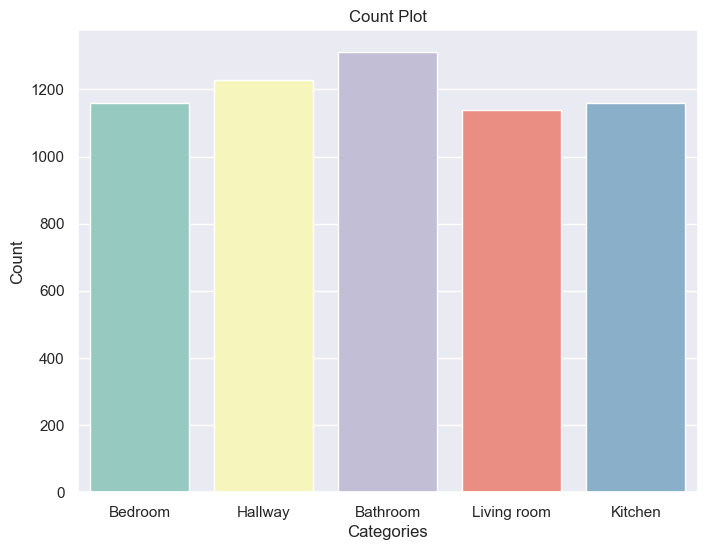

In [12]:
# Create a count plot
sns.set(style="darkgrid")  # Set the style of the plot
plt.figure(figsize=(8, 6))  # Set the figure size
# Replace 'dataset' with your actual DataFrame and 'Drug' with the column name
ax = sns.countplot(x='target', data=data, palette="Set3")
plt.title("Count Plot")  # Add a title to the plot
plt.xlabel("Categories")  # Add label to x-axis
plt.ylabel("Count")  # Add label to y-axis
# Annotate each bar with its count value

plt.show()  # Display the plot

In [13]:
# Converting object typew to int

In [14]:
le= LabelEncoder()      #call
data['target']=  le.fit_transform(data['target'])

In [15]:
# Defining Dependent and independent variables

In [16]:
X= data.iloc[:, 0:9]
X

,temperature,humidity,CO2CosIRValue,CO2MG811Value,MOX1,MOX2,MOX3,MOX4,COValue
0,23.490142,43.248217,356.825320,344.295932,0.996697,0.932151,1.117481,0.977576,0.117586
1,21.585207,48.554813,398.439826,368.453458,0.949635,0.969450,0.812102,0.978917,0.100786
2,23.943066,42.075801,400.900844,352.896991,0.982763,0.940262,0.967220,1.223543,0.081753
3,26.569090,46.920385,423.631517,372.600209,1.071473,1.011042,0.995834,1.080931,0.090750
4,21.297540,31.063853,331.657082,389.292485,1.127786,1.119718,1.001591,1.248065,0.106857
...,...,...,...,...,...,...,...,...,...
5995,25.210451,50.284576,408.573466,510.492783,1.130110,0.881881,1.061829,1.047039,0.119699
5996,21.920436,29.221882,457.632405,416.349726,0.800166,0.992718,1.041666,1.119036,0.084334
5997,19.354376,46.797022,339.129810,358.243775,0.929468,1.083801,0.961444,0.971721,0.115705
5998,21.510799,66.433782,423.397521,482.645653,1.049577,0.989930,1.019092,1.065469,0.077014


In [17]:
y= data['target']
y

0       1
1       2
2       0
3       4
4       1
       ..
5995    0
5996    3
5997    2
5998    4
5999    4
Name: target, Length: 6000, dtype: int32

In [18]:
# Feature Engineering (example: adding polynomial features)  #did not understand
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)   # call
X_poly = poly.fit_transform(X)

In [19]:
# Splitting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
#Standard scalars

In [22]:
X_train.shape

(4800, 9)

In [23]:
X_test.shape

(1200, 9)

In [24]:
labels = ['Kitchen', 'Hallway', 'Bathroom', 'Bedroom', 'Living room']

In [25]:
#defining global variables to store accuracy and other metrics
precision = []
recall = []
fscore = []
accuracy = []

In [26]:
#function to calculate various metrics such as accuracy, precision etc
def calculateMetrics(algorithm, predict, testY):
    testY = testY.astype('int')
    predict = predict.astype('int')
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100 
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+' Accuracy    : '+str(a))
    print(algorithm+' Precision   : '+str(p))
    print(algorithm+' Recall      : '+str(r))
    print(algorithm+' FSCORE      : '+str(f))
    report=classification_report(predict, testY,target_names=labels)
    print('\n',algorithm+" classification report\n",report)
    conf_matrix = confusion_matrix(testY, predict) 
    plt.figure(figsize =(5, 5)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="Blues" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") #correlation between target and features 
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show()

# DecisionTreeClassifier

DecisionTreeClassifier Accuracy    : 76.58333333333334
DecisionTreeClassifier Precision   : 77.04663058442935
DecisionTreeClassifier Recall      : 76.8069209439874
DecisionTreeClassifier FSCORE      : 76.65805846858386

 DecisionTreeClassifier classification report
               precision    recall  f1-score   support

     Kitchen       0.71      0.75      0.73       245
     Hallway       0.79      0.71      0.74       260
    Bathroom       0.83      0.71      0.77       257
     Bedroom       0.75      0.88      0.81       216
 Living room       0.76      0.80      0.78       222

    accuracy                           0.77      1200
   macro avg       0.77      0.77      0.77      1200
weighted avg       0.77      0.77      0.77      1200



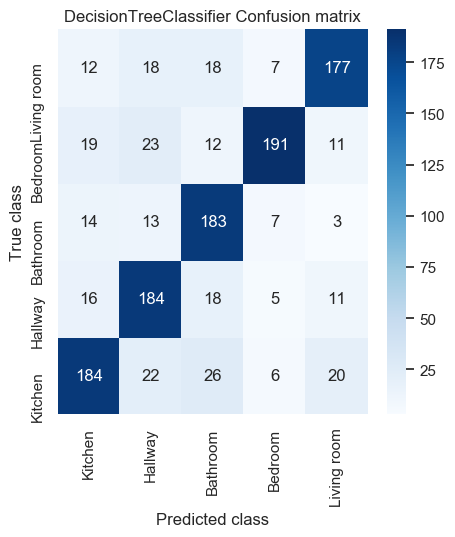

In [27]:
# Check if the pkl file exists
if os.path.exists('model/Dt_classifier_weights.pkl'):
    # Load the model from the pkl file
    dt_classifier= joblib.load('model/Dt_classifier_weights.pkl')
    predict = dt_classifier.predict(X_test)
    calculateMetrics("DecisionTreeClassifier", predict, y_test)
else:
    dt_classifier = DecisionTreeClassifier(criterion='entropy',splitter='best',max_depth=15)   #call
    # Train the classifier on the training data
    dt_classifier.fit(X_train, y_train)
    # Make predictions on the test data
    predict=dt_classifier.predict(X_test)
    joblib.dump(dt_classifier, 'model/dt_classifier_weights.pkl')
    print("dt_classifier_model trained and model weights saved.")
    calculateMetrics("DecisionTreeClassifier", predict, y_test)

# RFC

Model loaded successfully.
RandomForestClassifier Accuracy    : 95.5
RandomForestClassifier Precision   : 95.46316038827408
RandomForestClassifier Recall      : 95.50062656202392
RandomForestClassifier FSCORE      : 95.46928456695608

 RandomForestClassifier classification report
               precision    recall  f1-score   support

     Kitchen       0.97      0.95      0.96       261
     Hallway       0.95      0.96      0.95       231
    Bathroom       0.97      0.93      0.95       229
     Bedroom       0.95      0.98      0.96       250
 Living room       0.94      0.95      0.94       229

    accuracy                           0.95      1200
   macro avg       0.96      0.95      0.95      1200
weighted avg       0.96      0.95      0.95      1200



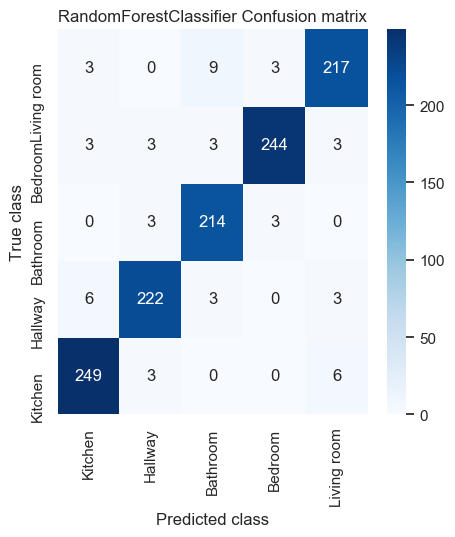

In [28]:
if os.path.exists('model/RandomForestClassifier.pkl'):
    # Load the trained model from the file
    rf = joblib.load('model/RandomForestClassifier.pkl')
    print("Model loaded successfully.")
    predict = rf.predict(X_test)
    calculateMetrics("RandomForestClassifier", predict, y_test)
else:
    # Train the model (assuming X_train and y_train are defined)
    rf = RandomForestClassifier()
    rf.fit(X_train, y_train)
    # Save the trained model to a file
    joblib.dump(rf, 'model/RandomForestClassifier.pkl')
    print("Model saved successfully.")
    predict = rf.predict(X_test)
    calculateMetrics("RandomForestClassifier", predict, y_test)

In [31]:
#Performance Comparision of both the algorithmns

In [29]:
#showing all algorithms performance values
columns = ["Algorithm Name","Precision","Recall","FScore","Accuracy"]
values = [] #This list will store performance data for each algorithm as sublists, 
             #with each sublist representing a different algorithm's performance metrics.


algorithm_names = ["DecisionTreeClassifier","RandomForestClassifier"]
for i in range(len(algorithm_names)):
    values.append([algorithm_names[i],precision[i],recall[i],fscore[i],accuracy[i]])
    
temp = pd.DataFrame(values,columns=columns)
temp

,Algorithm Name,Precision,Recall,FScore,Accuracy
0,DecisionTreeClassifier,77.046631,76.806921,76.658058,76.583333
1,RandomForestClassifier,95.463160,95.500627,95.469285,95.500000


In [29]:
# Prediction on new test data 

In [38]:
test=pd.read_csv("dataset/test.csv")

In [39]:
test

,temperature,humidity,CO2CosIRValue,CO2MG811Value,MOX1,MOX2,MOX3,MOX4,COValue,RoomType
0,24.54,46.10,126,592,449,723,679,592,121,Bedroom
1,22.96,44.43,120,581,439,725,682,615,128,Bedroom
2,22.34,51.09,88,536,512,717,672,614,106,Bedroom
3,22.73,54.87,107,506,502,711,651,595,123,Kitchen
4,17.45,55.12,116,525,556,749,708,662,103,Kitchen
...,...,...,...,...,...,...,...,...,...,...
95,22.14,49.42,112,500,463,668,600,542,175,Bedroom
96,24.16,49.13,101,531,503,698,656,588,106,Living room
97,15.80,57.43,73,508,584,742,706,653,105,Bathroom
98,23.15,49.48,105,523,500,702,660,594,118,Living room


In [40]:
test = test.drop(columns=['RoomType'])

In [41]:
scaled_test=scaler.fit_transform(test) #the fit_transform method standardizes or normalizes the data
#scaled test holds the transformed (scaled) values.

In [42]:
# Make predictions on the selected test data
predict = rf.predict(scaled_test)
# Loop through each prediction and print the corresponding row
for i, p in enumerate(predict):
    print(test.iloc[i])  # Print the row
    print(f"Row {i}:************************************************** {labels[p]}")

temperature       24.54
humidity          46.10
CO2CosIRValue    126.00
CO2MG811Value    592.00
MOX1             449.00
MOX2             723.00
MOX3             679.00
MOX4             592.00
COValue          121.00
Name: 0, dtype: float64
Row 0:************************************************** Bathroom
temperature       22.96
humidity          44.43
CO2CosIRValue    120.00
CO2MG811Value    581.00
MOX1             439.00
MOX2             725.00
MOX3             682.00
MOX4             615.00
COValue          128.00
Name: 1, dtype: float64
Row 1:************************************************** Hallway
temperature       22.34
humidity          51.09
CO2CosIRValue     88.00
CO2MG811Value    536.00
MOX1             512.00
MOX2             717.00
MOX3             672.00
MOX4             614.00
COValue          106.00
Name: 2, dtype: float64
Row 2:************************************************** Bathroom
temperature       22.73
humidity          54.87
CO2CosIRValue    107.00
CO2MG811Val

In [43]:
test['predict']=predict

In [44]:
test['Predicted'] = [labels[p] for p in predict]

In [45]:
test

,temperature,humidity,CO2CosIRValue,CO2MG811Value,MOX1,MOX2,MOX3,MOX4,COValue,predict,Predicted
0,24.54,46.10,126,592,449,723,679,592,121,2,Bathroom
1,22.96,44.43,120,581,439,725,682,615,128,1,Hallway
2,22.34,51.09,88,536,512,717,672,614,106,2,Bathroom
3,22.73,54.87,107,506,502,711,651,595,123,0,Kitchen
4,17.45,55.12,116,525,556,749,708,662,103,3,Bedroom
...,...,...,...,...,...,...,...,...,...,...,...
95,22.14,49.42,112,500,463,668,600,542,175,1,Hallway
96,24.16,49.13,101,531,503,698,656,588,106,2,Bathroom
97,15.80,57.43,73,508,584,742,706,653,105,3,Bedroom
98,23.15,49.48,105,523,500,702,660,594,118,2,Bathroom
